# Phase 2 — From molecules to feature vectors

A model does not see a molecule. It sees a fixed-length row of floats, and
whatever that row fails to encode, the model cannot learn — no matter how deep
it is.

This notebook shows how we get from a QM9 record (a variable-length list of
elements and 3D coordinates) to a fixed-length vector, why the design is forced
rather than arbitrary, and what it costs.

The implementation lives in `src/molecular_property_predictor/features.py`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from molecular_property_predictor.data import geometry, load_qm9
from molecular_property_predictor.features import (
    N_MAX_ATOMS,
    composition_features,
    coulomb_matrix,
    eigenspectrum_features,
    load_features,
    pad_to,
    sort_by_row_norm,
    sorted_coulomb_features,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_qm9()

# One small molecule we can actually read off a heatmap.
molecule = df.iloc[1000]
z, xyz = geometry(molecule)

print(f"dataset : {len(df):,} molecules")
print(f"example : {molecule['smiles_relaxed']}  ({molecule['n_atoms']} atoms)")
print(f"elements: {molecule['elements']}")
print("\ncoordinates (Angstrom):")
print(np.round(xyz, 3))

dataset : 130,831 molecules
example : O=Cc1cnc[nH]1  (11 atoms)
elements: ['O' 'C' 'C' 'C' 'N' 'C' 'N' 'H' 'H' 'H' 'H']

coordinates (Angstrom):
[[-1.620e-01 -2.200e-02 -1.000e-03]
 [-3.700e-02  1.183e+00  8.000e-03]
 [ 1.236e+00  1.880e+00 -1.000e-03]
 [ 2.546e+00  1.433e+00 -1.900e-02]
 [ 3.420e+00  2.477e+00 -2.000e-02]
 [ 2.665e+00  3.563e+00 -4.000e-03]
 [ 1.346e+00  3.263e+00  9.000e-03]
 [-9.280e-01  1.854e+00  2.300e-02]
 [ 2.877e+00  4.060e-01 -3.000e-02]
 [ 3.027e+00  4.580e+00  0.000e+00]
 [ 5.800e-01  3.918e+00  2.300e-02]]


## 1. Why raw coordinates are not features

The array above is a perfectly good description of the molecule. It is also
unusable as a model input, for three separate reasons.

The molecule's LUMO energy does not change if we **translate** it, **rotate**
it, or **renumber** its atoms. But the coordinate array changes under all
three. A model fed raw coordinates would have to discover from data that these
transformations are meaningless — from finitely many examples, imperfectly, at
the cost of capacity that should have gone on chemistry.

So the encoding has to be invariant *by construction*. Everything below follows
from that one requirement.

In [2]:
# A proper rotation matrix: orthogonal, with determinant +1.
def random_rotation(seed):
    generator = np.random.default_rng(seed)
    rotation, upper = np.linalg.qr(generator.normal(size=(3, 3)))
    rotation = rotation * np.sign(np.diag(upper))
    if np.linalg.det(rotation) < 0:
        rotation[:, 0] *= -1
    return rotation


rotated = xyz @ random_rotation(1).T
translated = xyz + np.array([10.0, 0.0, 0.0])
order = np.random.default_rng(2).permutation(len(z))

print("Largest change in the raw coordinate array:")
print(f"  after rotation   : {np.abs(rotated - xyz).max():.3f} A")
print(f"  after translation: {np.abs(translated - xyz).max():.3f} A")
print(f"  after renumbering: {np.abs(xyz[order] - xyz).max():.3f} A")
print("\n...and the molecule is the same molecule in all three cases.")

Largest change in the raw coordinate array:
  after rotation   : 6.621 A
  after translation: 10.000 A
  after renumbering: 4.174 A

...and the molecule is the same molecule in all three cases.


## 2. The Coulomb matrix

$$
M_{ij} = \begin{cases}
0.5\,Z_i^{2.4} & i = j \\[4pt]
\dfrac{Z_i Z_j}{\lVert \mathbf{R}_i - \mathbf{R}_j \rVert} & i \neq j
\end{cases}
$$

The off-diagonal is the nuclear repulsion between atoms $i$ and $j$. It depends
only on the **distance** between them — and distances are unchanged by rotation
and translation. That is the whole trick: two of the three invariances come for
free, by construction, rather than being learned.

The diagonal is an empirical stand-in for the energy of the isolated atom. The
2.4 exponent was fitted, not derived; nothing physical hangs on it.

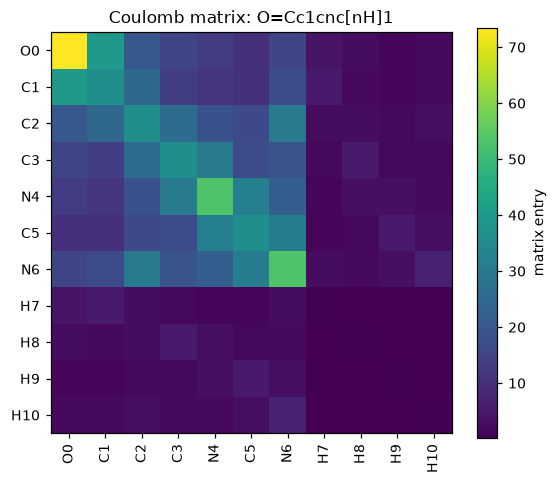

symmetric        : True
carbon diagonal  : 36.858  (0.5 * Z^2.4)
hydrogen diagonal: 0.500


In [3]:
matrix = coulomb_matrix(z, xyz)
labels = [f"{element}{i}" for i, element in enumerate(molecule["elements"])]

fig, ax = plt.subplots(figsize=(5.2, 4.4))
image = ax.imshow(matrix, cmap="viridis")
ax.set_xticks(range(len(labels)), labels, rotation=90)
ax.set_yticks(range(len(labels)), labels)
ax.set_title(f"Coulomb matrix: {molecule['smiles_relaxed']}")
fig.colorbar(image, label="matrix entry")
plt.tight_layout()
plt.show()

print(f"symmetric        : {np.allclose(matrix, matrix.T)}")
print(f"carbon diagonal  : {0.5 * 6 ** 2.4:.3f}  (0.5 * Z^2.4)")
print(f"hydrogen diagonal: {0.5 * 1 ** 2.4:.3f}")

The bright diagonal is the $0.5\,Z^{2.4}$ term — heavy atoms dominate it, which
is why the single oxygen and the carbons stand out against the hydrogens. The
off-diagonal structure is the geometry: close atom pairs are bright, distant
pairs are dim.

In [4]:
print("Largest change in the Coulomb matrix:")
print(f"  after rotation   : {np.abs(coulomb_matrix(z, rotated) - matrix).max():.2e}")
print(f"  after translation: {np.abs(coulomb_matrix(z, translated) - matrix).max():.2e}")
print("\nThat is floating-point noise, not a difference. Rotation and")
print("translation invariance are exact.")

Largest change in the Coulomb matrix:
  after rotation   : 1.42e-14
  after translation: 1.42e-14

That is floating-point noise, not a difference. Rotation and
translation invariance are exact.


## 3. The invariance we *don't* get for free

Renumbering the atoms permutes the rows and columns of the matrix. Same
molecule, different vector. Unlike rotation, this one has to be fixed by hand.

The standard fix is to sort rows and columns by descending row norm — an
ordering derived from the matrix itself, so the same molecule always sorts back
to the same arrangement whatever numbering it arrived in.

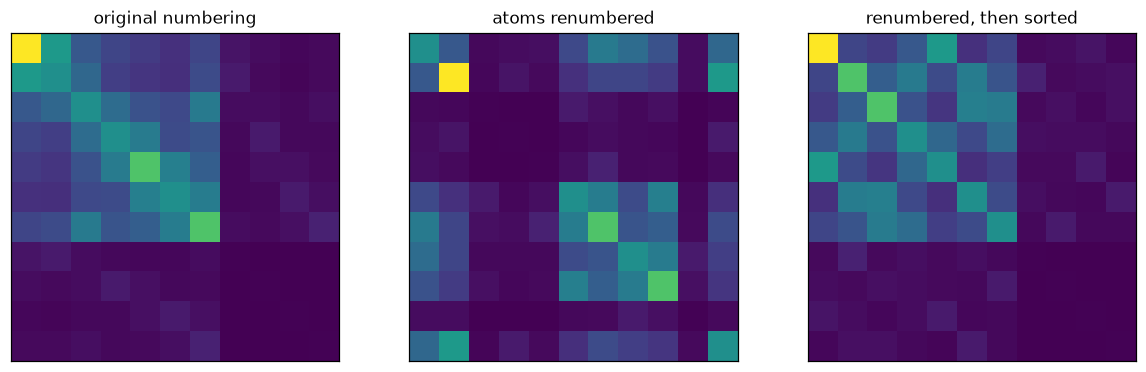

renumbered matrix equals original : False
after sorting, the two agree      : True


In [5]:
permuted = coulomb_matrix(z[order], xyz[order])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, data, title in zip(
    axes,
    [matrix, permuted, sort_by_row_norm(permuted)],
    ["original numbering", "atoms renumbered", "renumbered, then sorted"],
):
    ax.imshow(data, cmap="viridis", vmin=matrix.min(), vmax=matrix.max())
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"renumbered matrix equals original : "
      f"{np.allclose(permuted, matrix)}")
print(f"after sorting, the two agree      : "
      f"{np.allclose(sort_by_row_norm(permuted), sort_by_row_norm(matrix))}")

The middle panel is visibly scrambled; the right-hand panel is identical to a
sorted version of the left. Permutation invariance restored.

**Padding.** Molecules have between 3 and 29 atoms, so each matrix is zero-padded
out to 29×29 and the redundant lower triangle is dropped. That gives
$29 \times 30 / 2 = 435$ numbers per molecule, the same for every molecule. Real
rows always have a strictly positive norm, so the padding rows sort to the end
on their own.

## 4. What sorting costs

Sorting is not free, and the cost is worth understanding because it is the main
reason this representation was superseded.

The sort makes the map from geometry to feature vector **discontinuous**. Two
rows can have almost equal norms; a tiny nudge to the geometry flips their
order, and the feature vector jumps. Two nearly identical molecules can then sit
far apart in feature space — exactly the situation a regressor handles worst.

Below, we drag a single hydrogen along a straight line in 0.001 Å steps and
measure how far the feature vector moves at each step.

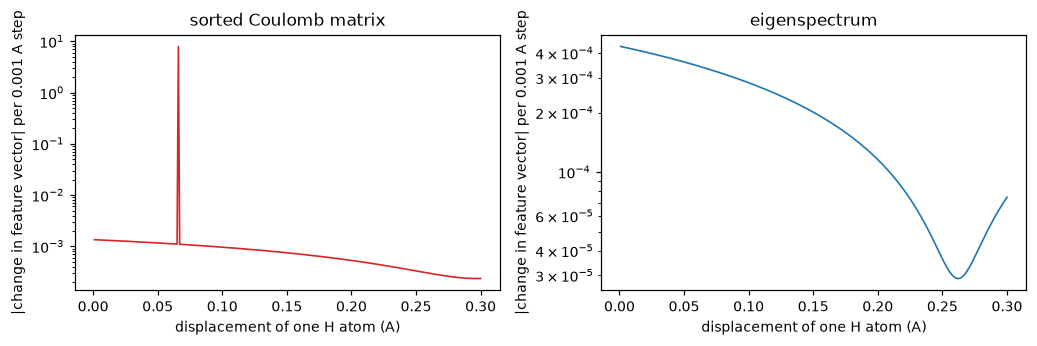

sorted CM : typical step 7.47e-04, largest 7.97e+00  (10,673x)
eigenspec : typical step 2.00e-04, largest 4.32e-04  (2.2x)

The spike is at a displacement of 0.066 A, where two row norms cross.


In [6]:
generator = np.random.default_rng(0)
direction = generator.normal(size=3)
direction /= np.linalg.norm(direction)
atom = 7  # a hydrogen whose row norm is nearly tied with its neighbour's

steps = np.linspace(0.0, 0.30, 301)
cm_change, eigen_change = [], []
previous_cm = sorted_coulomb_features(z, xyz)
previous_eigen = eigenspectrum_features(z, xyz)

for step in steps[1:]:
    moved = xyz.copy()
    moved[atom] += direction * step
    current_cm = sorted_coulomb_features(z, moved)
    current_eigen = eigenspectrum_features(z, moved)
    cm_change.append(np.linalg.norm(current_cm - previous_cm))
    eigen_change.append(np.linalg.norm(current_eigen - previous_eigen))
    previous_cm, previous_eigen = current_cm, current_eigen

cm_change = np.array(cm_change)
eigen_change = np.array(eigen_change)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharex=True)
for ax, data, title, colour in zip(
    axes,
    [cm_change, eigen_change],
    ["sorted Coulomb matrix", "eigenspectrum"],
    ["tab:red", "tab:blue"],
):
    ax.plot(steps[1:], data, color=colour, lw=1.1)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("displacement of one H atom (A)")
    ax.set_ylabel("|change in feature vector| per 0.001 A step")
plt.tight_layout()
plt.show()

print(f"sorted CM : typical step {np.median(cm_change):.2e}, "
      f"largest {cm_change.max():.2e}  ({cm_change.max() / np.median(cm_change):,.0f}x)")
print(f"eigenspec : typical step {np.median(eigen_change):.2e}, "
      f"largest {eigen_change.max():.2e}  ({eigen_change.max() / np.median(eigen_change):,.1f}x)")
print(f"\nThe spike is at a displacement of "
      f"{steps[1:][cm_change.argmax()]:.3f} A, where two row norms cross.")

Moving one hydrogen by a fraction of a bond length produces a spike four orders
of magnitude above the typical step. Physically nothing happened; the sort order
changed. The eigenspectrum, plotted alongside, has no such spike — eigenvalues
are invariant under permutation *exactly*, so nothing needs sorting.

This is the honest trade, and it is why we carry both representations into
Phase 3 rather than assuming the bigger one wins.

## 5. The three representations

We build three, and let Phase 3 measure them against each other rather than
guessing.

In [7]:
summary = pd.DataFrame(
    [
        {
            "representation": "composition",
            "features": 5,
            "uses geometry": "no",
            "permutation invariant": "yes",
            "continuous": "yes",
            "note": "control: atom counts only",
        },
        {
            "representation": "eigenspectrum",
            "features": N_MAX_ATOMS,
            "uses geometry": "yes",
            "permutation invariant": "yes (exactly)",
            "continuous": "yes",
            "note": "compact, but lossy",
        },
        {
            "representation": "sorted_coulomb",
            "features": N_MAX_ATOMS * (N_MAX_ATOMS + 1) // 2,
            "uses geometry": "yes",
            "permutation invariant": "yes (by sorting)",
            "continuous": "no",
            "note": "most information, discontinuous",
        },
    ]
).set_index("representation")

display(summary.style.set_caption("Phase 2 representations"))

,features,uses geometry,permutation invariant,continuous,note
representation,,,,,
composition,5,no,yes,yes,control: atom counts only
eigenspectrum,29,yes,yes (exactly),yes,"compact, but lossy"
sorted_coulomb,435,yes,yes (by sorting),no,"most information, discontinuous"


The **composition** row is the control, and it earns its place. Phase 1 found
that a model knowing nothing but per-element atom counts already explains
$R^2 = 0.4555$ of the variance in `lumo`. If a geometry-based representation
cannot beat five integers, the geometry is buying us nothing — and we want to
find that out now, not after training a network.

In [8]:
features = {kind: load_features(df, kind) for kind in
            ("composition", "eigenspectrum", "sorted_coulomb")}

for kind, matrix_of_features in features.items():
    print(f"{kind:<16} shape {str(matrix_of_features.shape):<14} "
          f"dtype {matrix_of_features.dtype}  "
          f"{matrix_of_features.nbytes / 1e6:>6.0f} MB")

composition      shape (130831, 5)    dtype float32       3 MB
eigenspectrum    shape (130831, 29)   dtype float32      15 MB
sorted_coulomb   shape (130831, 435)  dtype float32     228 MB


`float32`, not `float64` — it is the precision PyTorch works in by default, and
it halves 456 MB to 228 MB for the full sorted-Coulomb matrix. The matrices are
cached to `data/processed/` alongside the molecule indices they were built from,
so a cache from one subset can never be silently reused for another.

## 6. What we deliberately did *not* do here: scaling

In [9]:
scales = pd.DataFrame(
    {
        kind: {
            "min column std": matrix_of_features.std(axis=0).min(),
            "max column std": matrix_of_features.std(axis=0).max(),
            "min value": matrix_of_features.min(),
            "max value": matrix_of_features.max(),
        }
        for kind, matrix_of_features in features.items()
    }
).T

display(scales.style.format("{:.4g}").set_caption("Raw feature scales"))

,min column std,max column std,min value,max value
composition,0.2167,2.818,0,20
eigenspectrum,0.0005887,15.67,-1.57,304.1
sorted_coulomb,0.003627,14.56,0,97.53


The columns are on wildly different scales, and some are very nearly constant.
Models will need them standardised — but **the scaler must be fitted on the
training split alone**.

This is a real leakage trap, and an easy one to fall into. `StandardScaler` fitted
on the whole dataset computes means and standard deviations that include the test
molecules. Those statistics then flow into the training data, and the test score
comes out flattering and wrong. The fix is not subtle, just easy to forget: fit
the scaler inside the pipeline, on the training set, and apply it unchanged to
validation and test. That happens in Phase 3, which is why this notebook emits
raw features and stops.

The near-constant columns above (a standard deviation of 4×10⁻³ on some
sorted-Coulomb entries) are worth remembering too: dividing by a tiny standard
deviation amplifies whatever noise is in that column.

## 7. Honest limits

- The sorted Coulomb matrix is a **2012 representation**. SOAP, ACSF and
  message-passing graph neural networks have since replaced it, and reach errors
  on QM9 that nothing in this project will approach. It is used here because it
  is transparent, self-contained and about forty lines of NumPy — not because it
  is the best available.
- The discontinuity demonstrated in §4 is a genuine defect, not a technicality.
- The representation encodes nuclear charges and geometry only. It has no
  explicit notion of bonds, aromaticity, or electronic structure; whatever it
  gets right about LUMO, it gets from the arrangement of nuclei alone.

## What Phase 3 does with this

Fit a scikit-learn baseline on each of the three representations, on the same
seeded split, and compare against the mean-prediction baseline of **1.0510 eV
MAE**. That tells us which representation is worth carrying into PyTorch — and
whether the geometry is earning its keep at all.